# Análisis Exploratorio — Modelo de Probabilidad de Default

**Andina Crédito · Desafío Data Scientist**

Objetivo del cuaderno: entender la calidad de los datos y las características del
problema *antes* de modelar. Se documentan los hallazgos que fundamentan las
decisiones de limpieza (`src/data_prep.py`) y el diseño de validación (`src/train.py`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIG = Path("../reports/figures"); FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")
print("train:", train.shape, "| test:", test.shape)
train.head(3)

train: (45300, 21) | test: (12000, 20)


,id_solicitud,fecha_solicitud,edad,tipo_empleo,ingreso_declarado,antiguedad_laboral_meses,region,canal,antiguedad_cliente_meses,score_buro,deuda_sistema,num_creditos_vigentes,peor_morosidad_12m,num_consultas_buro_3m,num_contactos_ult_trimestre,uso_linea_credito_pct,monto_solicitado,plazo_meses,tasa_interes_anual,dia_semana_solicitud,default_12m
0,100000,2024-07-30,36,dependiente,1307000.0,102.0,Maule,partner,70,559,460000.0,3,0,2,0,11.1,5050000.0,48,22.8,lun,0
1,100001,2024-06-16,63,independiente,782.0,146.0,Biobio,sucursal,76,620,1679000.0,1,0,1,1,68.0,590000.0,12,20.7,vie,0
2,100002,2024-08-18,42,independiente,NaN,15.0,Nuble,partner,58,675,4267000.0,2,30,1,0,59.2,1440000.0,24,19.2,mar,0


## 1. Panorama general y target

El target `default_12m` indica mora de 90+ días dentro de los 12 meses posteriores
al desembolso. Revisamos la tasa base (que define el desbalance) y los nulos.

In [2]:
tasa = train["default_12m"].mean()
print(f"Tasa base de default: {tasa*100:.2f}%  (desbalance ~1:{(1-tasa)/tasa:.0f})")

print("\nNulos por columna (train):")
nul = train.isna().sum()
print(nul[nul > 0] if nul.sum() else "Sin nulos declarados como NaN")

Tasa base de default: 9.93%  (desbalance ~1:9)

Nulos por columna (train):
ingreso_declarado           8205
antiguedad_laboral_meses    7300
dtype: int64


**Lectura.** Desbalance moderado (~10% de default): el *accuracy* es inútil como
métrica (aprobar todo acierta ~90%); usaremos ranking (AUC / KS) y calibración. Los
nulos de `ingreso_declarado` (~18%) y `antiguedad_laboral_meses` (~16%) son altos y
probablemente **no aleatorios** (un informal o jubilado puede no declarar antigüedad
laboral): el faltante en sí puede ser predictivo → añadiremos indicadores de faltante.

## 2. Estructura temporal (define la validación)

El train y el test están separados en el tiempo. Esto obliga a validar *out-of-time*,
no con k-fold aleatorio (que filtraría el futuro y daría una estimación optimista).

In [3]:
for nombre, df in [("train", train), ("test", test)]:
    f = pd.to_datetime(df["fecha_solicitud"])
    print(f"{nombre}: {f.min().date()}  ->  {f.max().date()}")

train: 2024-01-01  ->  2025-02-14
test: 2025-02-14  ->  2025-06-30


## 3. Anomalía de ingreso: hipótesis de error de unidad

Se detectan ingresos imposibles (< 10.000 CLP, algunos de ~280). Hipótesis: error de
**unidad** (registro en miles en vez de pesos). Se valida por tres vías.

In [4]:
# (a) ¿Cuántos son, y están también en test?
for nombre, df in [("train", train), ("test", test)]:
    ing = df["ingreso_declarado"]; n_low = (ing < 10_000).sum()
    print(f"{nombre}: {n_low} valores < 10.000 CLP ({n_low/ing.notna().sum()*100:.1f}% de no-nulos)")


train: 4573 valores < 10.000 CLP (12.3% de no-nulos)
test: 1134 valores < 10.000 CLP (11.7% de no-nulos)


In [5]:

# (b) Reconciliación: al multiplicar ×1000, ¿calza la distribución con la normal?
ing = train["ingreso_declarado"]
normal = ing[ing >= 10_000]; anom = ing[ing < 10_000] * 1000
print("\nCuantil        normal        anómalo×1000")
for q in [0.25, 0.5, 0.75]:
    print(f"  p{int(q*100):<3}  {normal.quantile(q):>12,.0f}  {anom.quantile(q):>15,.0f}")



Cuantil        normal        anómalo×1000
  p25        609,000          612,000
  p50        848,000          851,000
  p75      1,174,000        1,183,000


In [6]:

# (c) Señal de negocio: el grupo anómalo NO tiene default de indigente
low = train[train["ingreso_declarado"] < 10_000]
print(f"\nDefault grupo anómalo: {low['default_12m'].mean()*100:.2f}% vs general: {tasa*100:.2f}%")


Default grupo anómalo: 8.31% vs general: 9.93%


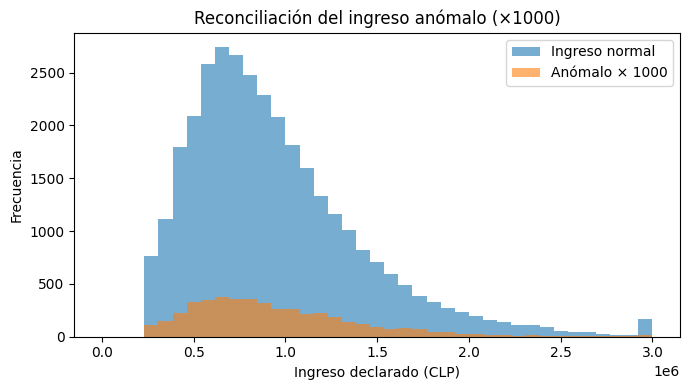

In [7]:
# Figura: histograma normal vs anómalo corregido (×1000)
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 3_000_000, 40)
ax.hist(normal.clip(upper=3_000_000), bins=bins, alpha=0.6, label="Ingreso normal")
ax.hist(anom.clip(upper=3_000_000), bins=bins, alpha=0.6, label="Anómalo × 1000")
ax.set(title="Reconciliación del ingreso anómalo (×1000)",
       xlabel="Ingreso declarado (CLP)", ylabel="Frecuencia")
ax.legend(); fig.tight_layout()
fig.savefig(FIG / "reconciliacion_ingreso.png", dpi=120); plt.show()

**Conclusión.** Las tres señales apuntan al mismo error de unidad: (1) el factor de
magnitud es ~1000; (2) al multiplicar ×1000 la distribución **completa** (p25/p50/p75)
se superpone con la de ingresos normales; (3) la tasa de default del grupo es la de un
cliente normal, no la de un indigente. → **Decisión:** corregir ×1000 los valores
< 10.000 como regla determinística (aplicada idéntica a train y test) y añadir un
indicador `ingreso_fue_corregido` como seguro ante correcciones imperfectas.

## 4. Valores imposibles y consistencia de categóricas

In [8]:
print("edad > 100:", (train["edad"] > 100).sum(), "casos (máx", train["edad"].max(), ")")
print("antiguedad_laboral > 600 meses:", (train["antiguedad_laboral_meses"] > 600).sum(),
      "casos (máx", int(train["antiguedad_laboral_meses"].max()), ")")

print("\nConsistencia de categóricas:")
for c in ["tipo_empleo", "canal", "region", "dia_semana_solicitud"]:
    print(f"  {c}: {sorted(train[c].dropna().unique())}")

edad > 100: 70 casos (máx 133 )
antiguedad_laboral > 600 meses: 20 casos (máx 936 )

Consistencia de categóricas:
  tipo_empleo: ['dependiente', 'independiente', 'informal', 'jubilado']
  canal: ['digital', 'partner', 'sucursal']
  region: ['Antofagasta', 'Araucania', 'Arica', 'Atacama', 'Aysen', 'Biobio', 'Coquimbo', 'Los Lagos', 'Los Rios', 'Magallanes', 'Maule', 'Metropolitana', 'Nuble', 'OHiggins', 'Tarapaca', 'Valparaiso']
  dia_semana_solicitud: ['dom', 'jue', 'lun', 'mar', 'mie', 'sab', 'vie']


**Lectura.** Las categóricas están limpias (16 regiones bien escritas, sin
duplicados de mayúsculas). Las edades > 100 (70 casos) y antigüedades > 600 meses
(20 casos) son errores puntuales sin patrón de centinela → se tratan como faltantes
(impacto marginal, pero documentado).

## 5. Default por vintage: madurez del target y tendencia

Chequeo clave: si hubiera *labels inmaduros* (créditos recientes sin 12 meses cumplidos),
la tasa de default caería en los meses recientes. Verificamos.

,n,tasa
mes,,
2024-01,3397,7.07
2024-02,3228,7.99
2024-03,3401,7.91
2024-04,3346,7.92
2024-05,3357,8.28
2024-06,3271,9.51
2024-07,3407,9.98
2024-08,3356,10.55
2024-09,3395,11.19


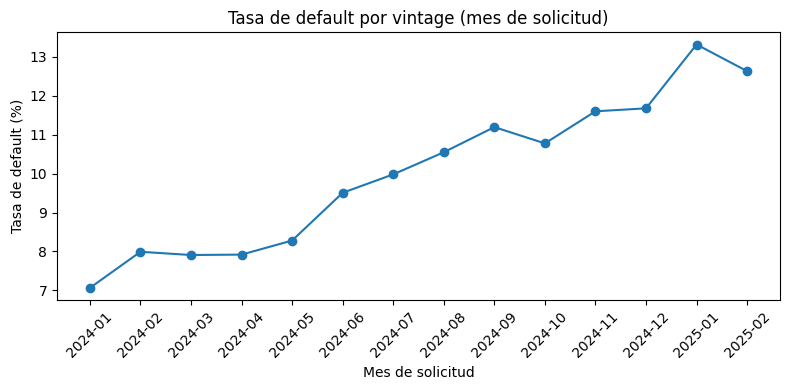

In [9]:
t = train.copy()
t["mes"] = pd.to_datetime(t["fecha_solicitud"]).dt.to_period("M")
g = t.groupby("mes").agg(n=("default_12m", "size"), tasa=("default_12m", "mean"))
display(g.assign(tasa=(g["tasa"]*100).round(2)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(g.index.astype(str), g["tasa"]*100, marker="o")
ax.set(title="Tasa de default por vintage (mes de solicitud)",
       xlabel="Mes de solicitud", ylabel="Tasa de default (%)")
ax.tick_params(axis="x", rotation=45); fig.tight_layout()
fig.savefig(FIG / "default_por_vintage.png", dpi=120); plt.show()

**Conclusión (doble).**

- *Metodológica:* la tasa **sube** hacia los meses recientes (7% → 13%), no cae → **no
  hay evidencia de censura / labels inmaduros**. La ventana out-of-time reciente es
  segura para validar.
- *De negocio:* ese ascenso es el **deterioro de mora** que motivó el proyecto, visible
  en los datos. Implica que entrenar con todo el histórico por igual **subestima el
  riesgo actual**, y que el test (aún más reciente) probablemente tiene una tasa mayor
  (*drift*). → Se explorará **ponderación por recencia** y se validará out-of-time sobre
  los meses recientes.

## Resumen de decisiones para `data_prep.py`

| Hallazgo | Decisión |
|---|---|
| Ingreso < 10.000 CLP (error de unidad) | Corregir ×1000 + indicador `ingreso_fue_corregido` |
| Nulos de ingreso / antigüedad (~16-18%, no aleatorios) | Imputar + indicador de faltante por variable |
| Edad > 100 / antigüedad > 600 meses | Tratar como faltante (marginal) |
| Categóricas | Limpias; codificar (one-hot / target/ordinal según modelo) |
| Split temporal + tendencia al alza | Validación out-of-time + explorar ponderación por recencia |